In [2]:
%pip install pytorch_msssim


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.listdir("output_mdn_updated_mrm_updated/run2/checkpoints")

['ckpt_0100.pt',
 'best_G.pt',
 'ckpt_0080.pt',
 'ckpt_0060.pt',
 'ckpt_0020.pt',
 'ckpt_0040.pt']

In [1]:
# ============================================================================
# IMPORTS
# ============================================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from timm import create_model
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from pytorch_msssim import ssim as ssim_loss  # pip install pytorch-msssim

# ============================================================================
# Helper Functions
# ============================================================================

def find_latest_checkpoint(output_dir: str):
    """Returns path to the most recent numbered checkpoint, or None."""
    ckpt_dir = output_dir
    if not os.path.isdir(ckpt_dir):
        return None
    ckpts = sorted([
        os.path.join(ckpt_dir, f)
        for f in os.listdir(ckpt_dir)
        if f.endswith(".pth") and "best" not in f   # skip best_G.pt
    ])
    return ckpts[-1] if ckpts else None


def resolve_checkpoint(resume_ckpt, output_dir: str):
    """
    Resolves which checkpoint to load:
      - If resume_ckpt == "none"  → start from scratch
      - If resume_ckpt is a path  → load that file
      - If resume_ckpt is None    → auto-detect latest checkpoint in output_dir
    """
    if isinstance(resume_ckpt, str) and resume_ckpt.lower() == "none":
        print("RESUME_CKPT='none': starting from scratch.")
        return None
    if resume_ckpt is not None:
        if os.path.isfile(resume_ckpt):
            print(f"Resuming from: {resume_ckpt}")
            return resume_ckpt
        raise FileNotFoundError(f"RESUME_CKPT not found: {resume_ckpt}")
    latest = find_latest_checkpoint(output_dir)
    if latest:
        print(f"Auto-detected latest checkpoint: {latest}")
    else:
        print("No checkpoint found – starting from scratch.")
    return latest


def load_checkpoint(ckpt_path: str, model, optimizer, device):
    """
    Loads model + optimizer state from a checkpoint file.

    Returns:
        start_epoch : int    – epoch to resume from
        history     : dict   – loss history dict (FIX: was using GAN keys)
        best_loss   : float  – best loss seen so far
    """
    print(f"\nLoading checkpoint: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    start_epoch = ckpt["epoch"]
    best_loss   = ckpt.get("best_val_loss", float("inf"))

    print(f"  Resumed at epoch {start_epoch}  |  best loss so far: {best_loss:.4f}")

    history = {"loss": []}
    history_path = os.path.join(
        os.path.dirname(os.path.dirname(ckpt_path)), "loss_history.json"
    )
    if os.path.isfile(history_path):
        with open(history_path) as f:
            saved = json.load(f)
        history["loss"] = saved.get("loss", [])[:start_epoch]
        print(f"  Restored loss history up to epoch {start_epoch}.")

    return start_epoch, history, best_loss

# ============================================================================
# DATASET CLASS
# ============================================================================

class ImageDataset(Dataset):
    def __init__(self, data_dir, target_slices=["slice_77", "slice_75"], mask_ratio=0.15, patch_size=16):
        self.data_dir = data_dir
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
        
        self.comp_dir = []
        for img in os.listdir(self.data_dir):
            img_path = os.path.join(self.data_dir, img)
            if (img_path.lower().endswith(('.png', '.jpg', '.jpeg')) and
                    'seg' not in os.path.basename(img_path)):
                if target_slices is None or any(s in os.path.basename(img_path) for s in target_slices):
                    self.comp_dir.append(img_path)
        
        self.data_len = len(self.comp_dir)
        print(f"Found {self.data_len} images in {data_dir}")
        
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])  # [-1, 1]
        ])

    def mask_image(self, image_tensor, mask_ratio=0.15, patch_size=16):
        """
        Create masked version and mask separately.
        Returns: masked_image, mask
        """
        squeeze_needed = False
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
            squeeze_needed = True

        B, C, H, W = image_tensor.shape
        num_patches_h = H // patch_size
        num_patches_w = W // patch_size
        num_patches = num_patches_h * num_patches_w
        num_masked = int(num_patches * mask_ratio)

        mask_indices = torch.randperm(num_patches)[:num_masked]
        mask = torch.ones(B, C, H, W, device=image_tensor.device)

        for idx in mask_indices:
            i = idx // num_patches_w
            j = idx % num_patches_w
            mask[:, :, i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] = 0

        masked_image = image_tensor * mask

        if squeeze_needed:
            masked_image = masked_image.squeeze(0)
            mask = mask.squeeze(0)

        return masked_image, mask

    def __len__(self):
        return self.data_len

    def __getitem__(self, idx):
        img_path = self.comp_dir[idx]
        try:
            image = Image.open(img_path).convert('L')
            image_tensor = self.transform(image)

            if torch.isnan(image_tensor).any() or torch.isinf(image_tensor).any():
                print(f"Warning: Invalid tensor at {img_path}")
                image_tensor = torch.zeros(1, 224, 224)

            masked_image_tensor, mask = self.mask_image(
                image_tensor,
                
                mask_ratio=self.mask_ratio,
                patch_size=self.patch_size
            )

            return masked_image_tensor, image_tensor, mask

        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            dummy = torch.zeros(1, 224, 224)
            return dummy, dummy, torch.ones(1, 224, 224)


# ============================================================================
# LOSS FUNCTION
# ============================================================================

def combined_loss(reconstructed, original_imgs, masks):
    """
    Weighted L1 + SSIM loss on masked regions, with small penalty on visible regions
    to prevent the decoder from distorting what it can already see.
    """
    inv_mask = 1 - masks  # 1 where masked, 0 where visible

    # L1 on masked regions (primary signal)
    masked_l1 = F.l1_loss(reconstructed * inv_mask, original_imgs * inv_mask)

    # L1 on visible regions (small regularizer)
    visible_l1 = F.l1_loss(reconstructed * masks, original_imgs * masks)

    # SSIM on full image (values must be in [0, 1])
    recon_01 = (reconstructed + 1) / 2
    target_01 = (original_imgs + 1) / 2
    ssim_val = ssim_loss(recon_01, target_01, data_range=1.0, size_average=True)

    return masked_l1 + 0.1 * visible_l1 + 0.5 * (1 - ssim_val)


# ============================================================================
# MODEL CLASS
# ============================================================================

class SwinMAE(nn.Module):
    """Swin Transformer for Masked Autoencoder"""
    def __init__(self, img_size=224, patch_size=4, in_chans=1, embed_dim=96, pretrained=True):
        super().__init__()

        self.encoder = create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            in_chans=in_chans,
            num_classes=0,
            global_pool=''
        )

        self.encoder_dim = self.encoder.num_features  # 768 for swin_tiny

        # Main decoder: 5x upsample from 7x7 → 224x224
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(self.encoder_dim, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.GELU(),

            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.GELU(),
        )

        # Refinement head — extra conv layers to sharpen output
        self.refine = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(16, in_chans, kernel_size=1),
            nn.Tanh()  # Output in [-1, 1]
        )

    def forward(self, x):
        # Encoder
        features = self.encoder.forward_features(x)

        # Swin Transformer always outputs [B, H, W, C] from forward_features
        if features.dim() == 4:
            features = features.permute(0, 3, 1, 2).contiguous()
            assert features.shape[1] == self.encoder_dim, \
                f"Expected C={self.encoder_dim}, got shape {features.shape}"
        elif features.dim() == 3:
            B, N, C = features.shape
            H = W = int(N ** 0.5)
            features = features.transpose(1, 2).contiguous().view(B, C, H, W)
        else:
            raise ValueError(f"Unexpected feature dimension: {features.shape}")

        # Decoder + refinement
        x = self.decoder(features)
        reconstructed = self.refine(x)

        return reconstructed


# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc='Training')
    for masked_imgs, original_imgs, masks in pbar:
        masked_imgs = masked_imgs.to(device)
        original_imgs = original_imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        if scaler is not None:
            with torch.cuda.amp.autocast():
                reconstructed = model(masked_imgs)
                if reconstructed.shape != original_imgs.shape:
                    reconstructed = F.interpolate(
                        reconstructed, size=original_imgs.shape[-2:],
                        mode='bilinear', align_corners=False
                    )
                loss = combined_loss(reconstructed, original_imgs, masks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            reconstructed = model(masked_imgs)
            if reconstructed.shape != original_imgs.shape:
                reconstructed = F.interpolate(
                    reconstructed, size=original_imgs.shape[-2:],
                    mode='bilinear', align_corners=False
                )
            loss = combined_loss(reconstructed, original_imgs, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for masked_imgs, original_imgs, masks in tqdm(dataloader, desc='Validating'):
            masked_imgs = masked_imgs.to(device)
            original_imgs = original_imgs.to(device)
            masks = masks.to(device)

            reconstructed = model(masked_imgs)
            if reconstructed.shape != original_imgs.shape:
                reconstructed = F.interpolate(
                    reconstructed, size=original_imgs.shape[-2:],
                    mode='bilinear', align_corners=False
                )

            loss = combined_loss(reconstructed, original_imgs, masks)
            total_loss += loss.item()

    return total_loss / len(dataloader)


# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================

def calculate_metrics(original, reconstructed, mask):
    """Calculate reconstruction metrics"""
    original_np = ((original.cpu().numpy() + 1) / 2).clip(0, 1)
    reconstructed_np = ((reconstructed.cpu().numpy() + 1) / 2).clip(0, 1)
    mask_np = mask.cpu().numpy()

    masked_region = (1 - mask_np) > 0.5

    if masked_region.sum() == 0:
        return {'mse': 0, 'mae': 0, 'psnr': 0, 'ssim': 0}

    mse = mean_squared_error(original_np[masked_region], reconstructed_np[masked_region])
    mae = mean_absolute_error(original_np[masked_region], reconstructed_np[masked_region])
    psnr_val = psnr(original_np[0, 0], reconstructed_np[0, 0], data_range=1.0)
    ssim_val = ssim(original_np[0, 0], reconstructed_np[0, 0], data_range=1.0)

    return {'mse': mse, 'mae': mae, 'psnr': psnr_val, 'ssim': ssim_val}


def visualize_reconstructions(model, dataloader, device, num_samples=8, save_dir='visualizations'):
    """Visualize reconstruction results"""
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    samples_shown = 0

    with torch.no_grad():
        for masked_imgs, original_imgs, masks in dataloader:
            if samples_shown >= num_samples:
                break

            masked_imgs = masked_imgs.to(device)
            original_imgs = original_imgs.to(device)
            masks = masks.to(device)

            reconstructed = model(masked_imgs)
            if reconstructed.shape != original_imgs.shape:
                reconstructed = F.interpolate(
                    reconstructed, size=original_imgs.shape[-2:],
                    mode='bilinear', align_corners=False
                )

            batch_size = masked_imgs.shape[0]
            for i in range(min(batch_size, num_samples - samples_shown)):
                fig, axes = plt.subplots(1, 5, figsize=(20, 4))

                masked = ((masked_imgs[i, 0].cpu().numpy() + 1) / 2).clip(0, 1)
                original = ((original_imgs[i, 0].cpu().numpy() + 1) / 2).clip(0, 1)
                recon = ((reconstructed[i, 0].cpu().numpy() + 1) / 2).clip(0, 1)
                mask = masks[i, 0].cpu().numpy()

                axes[0].imshow(original, cmap='gray')
                axes[0].set_title('Original Image')
                axes[0].axis('off')

                axes[1].imshow(mask, cmap='gray')
                axes[1].set_title(f'Mask ({(1-mask).mean()*100:.1f}% masked)')
                axes[1].axis('off')

                axes[2].imshow(masked, cmap='gray')
                axes[2].set_title('Masked Input')
                axes[2].axis('off')

                axes[3].imshow(recon, cmap='gray')
                axes[3].set_title('Reconstruction')
                axes[3].axis('off')

                diff = np.abs(original - recon)
                axes[4].imshow(diff, cmap='hot')
                axes[4].set_title(f'Difference (MAE: {diff.mean():.4f})')
                axes[4].axis('off')

                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, f'reconstruction_{samples_shown}.png'),
                            dpi=150, bbox_inches='tight')
                plt.close()

                samples_shown += 1
                if samples_shown >= num_samples:
                    break

    print(f"Saved {samples_shown} visualization samples to {save_dir}/")


def test_model(model, test_loader, device, save_dir='test_results'):
    """Comprehensive test evaluation"""
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    all_metrics = {'mse': [], 'mae': [], 'psnr': [], 'ssim': []}

    print("\nEvaluating on test set...")

    with torch.no_grad():
        for masked_imgs, original_imgs, masks in tqdm(test_loader, desc='Testing'):
            masked_imgs = masked_imgs.to(device)
            original_imgs = original_imgs.to(device)
            masks = masks.to(device)

            reconstructed = model(masked_imgs)
            if reconstructed.shape != original_imgs.shape:
                reconstructed = F.interpolate(
                    reconstructed, size=original_imgs.shape[-2:],
                    mode='bilinear', align_corners=False
                )

            batch_size = masked_imgs.shape[0]
            for i in range(batch_size):
                metrics = calculate_metrics(
                    original_imgs[i:i+1],
                    reconstructed[i:i+1],
                    masks[i:i+1]
                )
                for key in all_metrics:
                    all_metrics[key].append(metrics[key])

    print("\n" + "="*50)
    print("TEST RESULTS")
    print("="*50)

    results = {}
    for metric_name, values in all_metrics.items():
        mean_val = np.mean(values)
        std_val = np.std(values)
        median_val = np.median(values)
        results[metric_name] = {'mean': mean_val, 'std': std_val, 'median': median_val}
        print(f"{metric_name.upper()}:")
        print(f"  Mean: {mean_val:.6f}")
        print(f"  Std:  {std_val:.6f}")
        print(f"  Median: {median_val:.6f}")
        print()

    with open(os.path.join(save_dir, 'test_metrics.txt'), 'w') as f:
        f.write("="*50 + "\n")
        f.write("TEST RESULTS\n")
        f.write("="*50 + "\n\n")
        for metric_name, stats in results.items():
            f.write(f"{metric_name.upper()}:\n")
            f.write(f"  Mean: {stats['mean']:.6f}\n")
            f.write(f"  Std:  {stats['std']:.6f}\n")
            f.write(f"  Median: {stats['median']:.6f}\n\n")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Test Metrics Distribution', fontsize=16)

    for idx, (metric_name, values) in enumerate(all_metrics.items()):
        ax = axes[idx // 2, idx % 2]
        ax.hist(values, bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(np.mean(values), color='red', linestyle='--',
                   label=f'Mean: {np.mean(values):.4f}')
        ax.axvline(np.median(values), color='green', linestyle='--',
                   label=f'Median: {np.median(values):.4f}')
        ax.set_xlabel(metric_name.upper())
        ax.set_ylabel('Frequency')
        ax.set_title(f'{metric_name.upper()} Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'metric_distributions.png'), dpi=150, bbox_inches='tight')
    plt.close()

    print(f"Results saved to {save_dir}/")
    return results



In [2]:

# ============================================================================
# MAIN EXECUTION CODE
# ============================================================================

if __name__ == "__main__":

    # ========================================================================
    # CONFIGURATION
    # ========================================================================

    TRAIN_DIR = "Project/MRI_DATA/BraTS2021_Training_Data_2D/train"
    VAL_DIR   = "Project/MRI_DATA/BraTS2021_Training_Data_2D/val"
    TEST_DIR  = "Project/MRI_DATA/BraTS2021_Training_Data_2D/test"

    BATCH_SIZE     = 64
    EPOCHS         = 100
    LR             = 1e-4
    IMG_SIZE       = 224
    MASK_RATIO     = 0.25   # reduced from 0.50
    CHECKPOINT_DIR = "checkpoints"
    WARMUP_EPOCHS  = 5
    PATCH_SIZE = 16

    # ========================================================================
    # SETUP
    # ========================================================================

    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    print(f"PyTorch version: {torch.__version__}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")

    # ========================================================================
    # CREATE DATASETS
    # ========================================================================

    print("\n" + "="*70)
    print("CREATING DATASETS")
    print("="*70)

    train_dataset = ImageDataset(
        data_dir=TRAIN_DIR,
        target_slices=None,
        mask_ratio=MASK_RATIO,
        patch_size=PATCH_SIZE
    )
    val_dataset = ImageDataset(
        data_dir=VAL_DIR,
        target_slices=None,
        mask_ratio=MASK_RATIO,
        patch_size=PATCH_SIZE
    )
    test_dataset = ImageDataset(
        data_dir=TEST_DIR,
        target_slices=None,
        mask_ratio=MASK_RATIO,
        patch_size=PATCH_SIZE
    )
    print('Dataset created')

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=torch.cuda.is_available())

    print(f"\nTrain samples: {len(train_dataset)}")
    print(f"Val samples:   {len(val_dataset)}")
    print(f"Test samples:  {len(test_dataset)}")
    print(f"Batch size:    {BATCH_SIZE}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches:   {len(val_loader)}")
    print(f"Test batches:  {len(test_loader)}")

    # ========================================================================
    # CREATE MODEL
    # ========================================================================

    print("\n" + "="*70)
    print("CREATING MODEL")
    print("="*70)

    model = SwinMAE(img_size=IMG_SIZE, patch_size=4, in_chans=1, pretrained=True)
    model = model.to(device)

    total_params    = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # ========================================================================
    # SETUP TRAINING
    # ========================================================================

    # criterion is passed to train_epoch/validate but combined_loss is used internally
    criterion = nn.MSELoss()  # kept for API compatibility; actual loss = combined_loss

    # Differential learning rates: encoder fine-tuned slowly, decoder at full LR
    optimizer = optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR * 0.1},
        {'params': model.decoder.parameters(), 'lr': LR},
        {'params': model.refine.parameters(),  'lr': LR},
    ], weight_decay=0.05)

    # Linear warmup then cosine annealing
    def lr_lambda(epoch):
        if epoch < WARMUP_EPOCHS:
            return (epoch + 1) / WARMUP_EPOCHS
        progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
        return 0.5 * (1.0 + np.cos(np.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

    # ========================================================================
    # TRAINING LOOP
    # ========================================================================

    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70)

    best_val_loss = float('inf')
    train_losses  = []
    val_losses    = []
    resume_ckpt = None
    ckpt_path   = resolve_checkpoint(resume_ckpt, CHECKPOINT_DIR)
    start_epoch = 0
    best_loss   = float("inf")
    history     = {"loss": []}          

    if ckpt_path:
        start_epoch, history, best_val_loss = load_checkpoint(
            ckpt_path, model, optimizer, device
        )

    if EPOCHS - start_epoch <= 0:
        raise ValueError("epcoh error")
    for epoch in range(start_epoch+1, EPOCHS+1):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"{'='*70}")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        train_losses.append(train_loss)
        print(f"Train Loss: {train_loss:.6f}")

        val_loss = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        print(f"Val Loss:   {val_loss:.6f}")

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning Rate (encoder): {current_lr:.8f}")
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
            }, os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
            print(f"✓ Saved best model with val_loss: {val_loss:.6f}")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
            }, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pth'))
            print(f"✓ Saved checkpoint at epoch {epoch+1}")

        if (epoch + 1) % 5 == 0:
            visualize_reconstructions(
                model, val_loader, device, num_samples=4,
                save_dir=f'{CHECKPOINT_DIR}/visualizations_epoch_{epoch+1}'
            )

    # ========================================================================
    # PLOT TRAINING HISTORY
    # ========================================================================

    print("\n" + "="*70)
    print("PLOTTING TRAINING HISTORY")
    print("="*70)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(range(1, EPOCHS+1), val_losses,   label='Val Loss',   marker='s', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved training history plot to {CHECKPOINT_DIR}/training_history.png")

    # ========================================================================
    # FINAL EVALUATION ON TEST SET
    # ========================================================================

    print("\n" + "="*70)
    print("LOADING BEST MODEL FOR FINAL EVALUATION")
    print("="*70)

    checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pth'), map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
    print(f"Best validation loss: {checkpoint['val_loss']:.6f}")

    print("\n" + "="*70)
    print("RUNNING FINAL TEST EVALUATION")
    print("="*70)

    test_results = test_model(model, test_loader, device, save_dir='test_results')

    visualize_reconstructions(
        model, test_loader, device, num_samples=16,
        save_dir='test_results/visualizations'
    )

    # ========================================================================
    # SUMMARY
    # ========================================================================

    print("\n" + "="*70)
    print("TRAINING AND EVALUATION COMPLETE!")
    print("="*70)
    print(f"\nBest validation loss: {best_val_loss:.6f}")
    print(f"\nTest Results:")
    for metric_name, stats in test_results.items():
        print(f"  {metric_name.upper()}: {stats['mean']:.6f} ± {stats['std']:.6f}")

    print(f"\nCheckpoints saved to: {CHECKPOINT_DIR}/")
    print(f"Test results saved to: test_results/")
    print(f"Visualizations saved to: test_results/visualizations/")
    print("\n" + "="*70)

Using device: cuda
PyTorch version: 2.2.1+cu121
CUDA version: 12.1
GPU: NVIDIA GeForce GTX 1080 Ti

CREATING DATASETS
Found 70000 images in Project/MRI_DATA/BraTS2021_Training_Data_2D/train
Found 10080 images in Project/MRI_DATA/BraTS2021_Training_Data_2D/val
Found 20000 images in Project/MRI_DATA/BraTS2021_Training_Data_2D/test
Dataset created

Train samples: 70000
Val samples:   10080
Test samples:  20000
Batch size:    64
Train batches: 1094
Val batches:   158
Test batches:  313

CREATING MODEL
Total parameters:     29,802,331
Trainable parameters: 29,802,331

STARTING TRAINING
Auto-detected latest checkpoint: checkpoints/checkpoint_epoch_90.pth

Loading checkpoint: checkpoints/checkpoint_epoch_90.pth
  Resumed at epoch 89  |  best loss so far: inf

Epoch 91/100


Training:   1%|          | 12/1094 [00:11<16:40,  1.08it/s, loss=0.0614]


KeyboardInterrupt: 

2026-03-03 19:15:26.837534: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-03 19:15:26.837606: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-03 19:15:26.839970: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-03 19:15:26.854735: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


MRI MODALITY LATENT EXTRACTION AND UMAP VISUALIZATION

Device: cuda
Image directory: Project/MRI_DATA/BraTS2021_Training_Data_2D/val
Target slices: None

COLLECTING IMAGES BY MODALITY
Scanning directory: Project/MRI_DATA/BraTS2021_Training_Data_2D/val

Images found per modality:
  T1    : 2520 images
  T2    : 2520 images
  T1CE  : 2520 images
  FLAIR : 2520 images

Loading model from checkpoints/best_model.pth...
✓ Model loaded successfully!

EXTRACTING LATENTS FOR EACH MODALITY

T1: Processing 2520 images...
  ✓ Extracted shape: torch.Size([2520, 768, 7, 7])

T2: Processing 2520 images...
  ✓ Extracted shape: torch.Size([2520, 768, 7, 7])

T1CE: Processing 2520 images...
  ✓ Extracted shape: torch.Size([2520, 768, 7, 7])

FLAIR: Processing 2520 images...
  ✓ Extracted shape: torch.Size([2520, 768, 7, 7])

SAVING LATENTS
✓ Saved T1 latents to modality_analysis1/latents/t1_latents.pt
  Shape: torch.Size([2520, 768, 7, 7])
✓ Saved T2 latents to modality_analysis1/latents/t2_latents.pt
 

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Mar  3 19:18:30 2026 Construct fuzzy simplicial set
Tue Mar  3 19:18:32 2026 Finding Nearest Neighbors
Tue Mar  3 19:18:32 2026 Building RP forest with 10 trees
Tue Mar  3 19:19:05 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	 5  /  13
	 6  /  13
	Stopping threshold met -- exiting after 6 iterations
Tue Mar  3 19:19:57 2026 Finished Nearest Neighbor Search
Tue Mar  3 19:20:01 2026 Construct embedding


/opt/conda/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Mar  3 19:21:54 2026 Finished embedding
✓ UMAP completed! Embedded shape: (10080, 2)

Creating visualization...
✓ Saved UMAP plot to modality_analysis1/umap_modalities.png


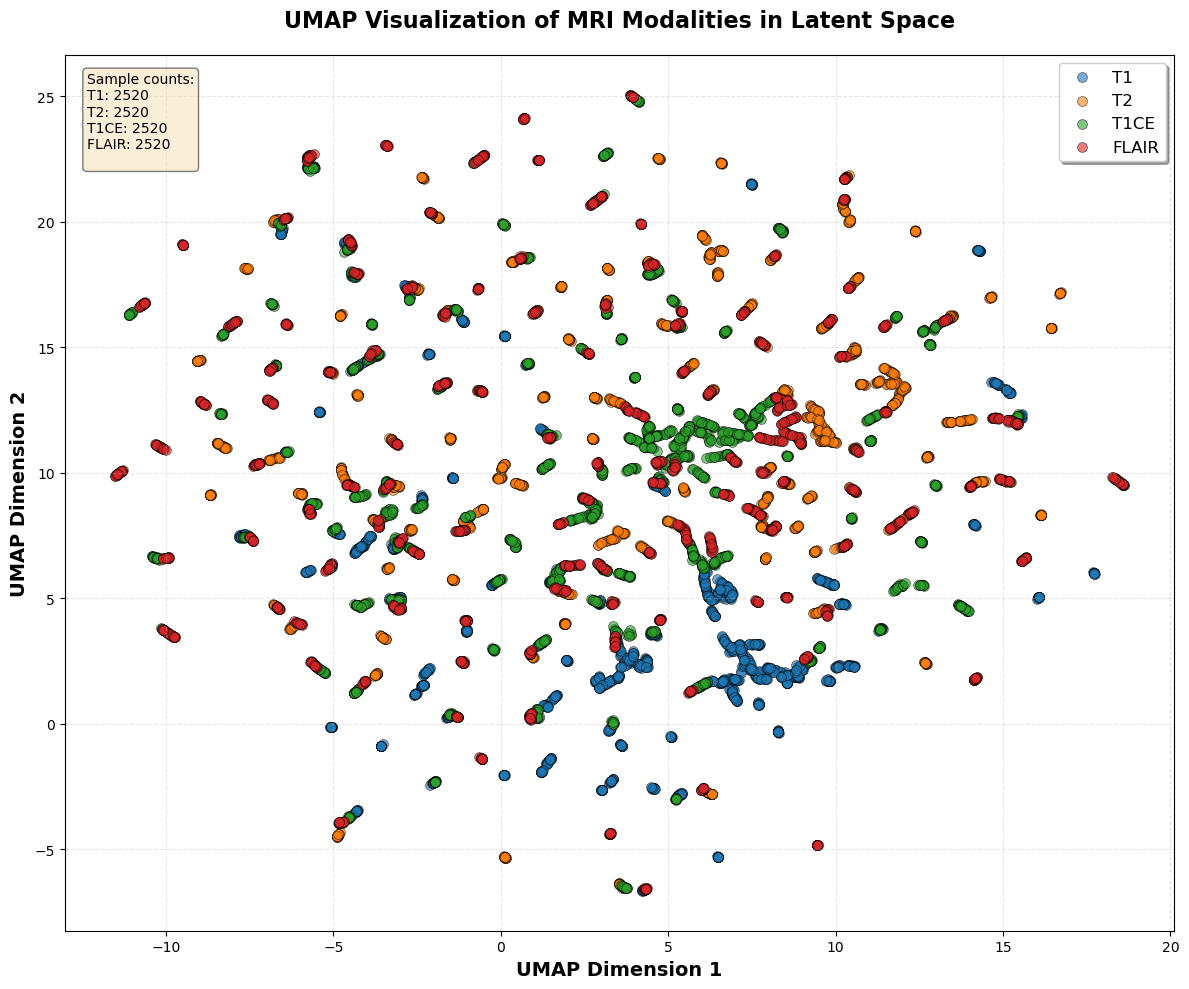


COMPLETE!

Processed modalities:
  T1    : 2520 samples, shape torch.Size([2520, 768, 7, 7])
  T2    : 2520 samples, shape torch.Size([2520, 768, 7, 7])
  T1CE  : 2520 samples, shape torch.Size([2520, 768, 7, 7])
  FLAIR : 2520 samples, shape torch.Size([2520, 768, 7, 7])

Outputs saved to: modality_analysis1/
  - UMAP plot: modality_analysis1/umap_modalities.png
  - Latents: modality_analysis1/latents/
  - Comparison plots: modality_analysis1/umap_comparison.png



In [1]:
"""
Extract Latents from Different MRI Modalities and Visualize with UMAP
This script processes T1, T2, T1CE, and FLAIR images separately and creates UMAP visualization
"""

import os
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
from torchvision import transforms
from timm import create_model
from tqdm import tqdm
import matplotlib.pyplot as plt
from umap import UMAP
import seaborn as sns


# ============================================================================
# MODEL CLASS
# ============================================================================

# ============================================================================
# MODEL CLASS  — must match training code exactly
# ============================================================================

class SwinMAE(nn.Module):
    """Swin Transformer for Masked Autoencoder"""
    def __init__(self, img_size=224, patch_size=4, in_chans=1, embed_dim=96, pretrained=True):
        super().__init__()

        self.encoder = create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            in_chans=in_chans,
            num_classes=0,
            global_pool=''
        )

        self.encoder_dim = self.encoder.num_features

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(self.encoder_dim, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512), nn.GELU(),
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256), nn.GELU(),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32), nn.GELU(),
        )

        # Refinement head — must match training code
        self.refine = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(16, in_chans, kernel_size=1),
            nn.Tanh()
        )

    def encode(self, x):
        """Extract latent features (encoder output only) — used for UMAP"""
        features = self.encoder.forward_features(x)

        if features.dim() == 4:
            features = features.permute(0, 3, 1, 2).contiguous()
            assert features.shape[1] == self.encoder_dim, \
                f"Expected C={self.encoder_dim}, got shape {features.shape}"
        elif features.dim() == 3:
            B, N, C = features.shape
            H = W = int(N ** 0.5)
            features = features.transpose(1, 2).contiguous().view(B, C, H, W)
        else:
            raise ValueError(f"Unexpected feature dimension: {features.shape}")

        return features

    def forward(self, x):
        features = self.encode(x)
        x = self.decoder(features)
        return self.refine(x)


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def identify_modality(filename):
    """
    Identify MRI modality from filename
    Returns: 't1', 't2', 't1ce', 'flair', or None
    """
    filename_lower = filename.lower()
    
    # Skip segmentation files
    if 'seg' in filename_lower:
        return None

    if 't1ce' in filename_lower:
        return 't1ce'
    elif 't1' in filename_lower:
        return 't1'
    elif 't2' in filename_lower:
        return 't2'
    elif 'flair' in filename_lower:
        return 'flair'
    
    return None


def collect_images_by_modality(image_dir, target_slices=["slice_77", "slice_75"]):
    """
    Collect image paths organized by modality
    
    Returns:
        dict: {modality: [list of image paths]}
    """
    modality_images = {
        't1': [],
        't2': [],
        't1ce': [],
        'flair': []
    }
    
    print(f"Scanning directory: {image_dir}")
    
    for img_name in os.listdir(image_dir):
        img_path = os.path.join(image_dir, img_name)
        
        # Check if it's an image file
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        
        # Check if it matches target slices (if specified)
        if target_slices and not any(s in img_name for s in target_slices):
            continue
        
        # Identify modality
        modality = identify_modality(img_name)
        
        if modality:
            modality_images[modality].append(img_path)
    
    # Print summary
    print("\nImages found per modality:")
    for modality, paths in modality_images.items():
        print(f"  {modality.upper():6s}: {len(paths):4d} images")
    
    return modality_images


def load_model(checkpoint_path, device='cuda'):
    """Load trained model from checkpoint"""
    print(f"\nLoading model from {checkpoint_path}...")
    
    model = SwinMAE(img_size=224, patch_size=4, in_chans=1, pretrained=False)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"✓ Model loaded successfully!")
    
    return model


def extract_latents_for_modality(model, image_paths, device, batch_size=16):
    """
    Extract latents for a list of images
    
    Returns:
        torch.Tensor: Latents of shape [N, C, H, W]
    """
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    all_latents = []
    
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_tensors = []
        
        for img_path in batch_paths:
            try:
                img = Image.open(img_path).convert('L')
                img_tensor = transform(img)
                batch_tensors.append(img_tensor)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
        
        if len(batch_tensors) > 0:
            batch = torch.stack(batch_tensors).to(device)
            
            with torch.no_grad():
                latents = model.encode(batch)
            
            all_latents.append(latents.cpu())
    
    if len(all_latents) > 0:
        return torch.cat(all_latents, dim=0)
    else:
        return torch.empty(0)


def extract_all_latents(model, modality_images, device, batch_size=16):
    """
    Extract latents for all modalities
    
    Returns:
        dict: {modality: latents_tensor}
    """
    all_latents = {}
    
    print("\n" + "="*70)
    print("EXTRACTING LATENTS FOR EACH MODALITY")
    print("="*70)
    
    for modality, image_paths in modality_images.items():
        if len(image_paths) == 0:
            print(f"\n{modality.upper()}: Skipping (no images)")
            continue
        
        print(f"\n{modality.upper()}: Processing {len(image_paths)} images...")
        latents = extract_latents_for_modality(model, image_paths, device, batch_size)
        
        if latents.shape[0] > 0:
            all_latents[modality] = latents
            print(f"  ✓ Extracted shape: {latents.shape}")
        else:
            print(f"  ✗ Failed to extract latents")
    
    return all_latents


def create_umap_visualization(all_latents, save_path='umap_modalities.png', n_components=2, n_neighbors=15):
    """
    Create UMAP visualization of latents from different modalities
    
    Args:
        all_latents: dict of {modality: latents_tensor}
        save_path: where to save the plot
        n_components: UMAP dimensions (2 for 2D plot)
        n_neighbors: UMAP parameter
    """
    print("\n" + "="*70)
    print("CREATING UMAP VISUALIZATION")
    print("="*70)
    
    # Prepare data
    all_latents_list = []
    all_labels = []
    modality_names = []
    
    for modality, latents in all_latents.items():
        # Flatten latents: [N, C, H, W] -> [N, C*H*W]
        latents_flat = latents.reshape(latents.shape[0], -1).numpy()
        all_latents_list.append(latents_flat)
        all_labels.extend([modality] * latents_flat.shape[0])
        modality_names.append(modality)
    
    # Concatenate all latents
    X = np.vstack(all_latents_list)
    
    print(f"\nTotal samples: {X.shape[0]}")
    print(f"Feature dimension: {X.shape[1]}")
    print(f"Modalities: {modality_names}")
    
    # Apply UMAP
    print(f"\nApplying UMAP (n_neighbors={n_neighbors}, n_components={n_components})...")
    umap_model = UMAP(n_components=n_components, n_neighbors=n_neighbors, random_state=42, verbose=True)
    X_umap = umap_model.fit_transform(X)
    
    print(f"✓ UMAP completed! Embedded shape: {X_umap.shape}")
    
    # Create visualization
    print(f"\nCreating visualization...")
    
    # Set up colors for each modality
    colors = {
        't1': '#1f77b4',    # Blue
        't2': '#ff7f0e',    # Orange
        't1ce': '#2ca02c',  # Green
        'flair': '#d62728'  # Red
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot each modality
    for modality in modality_names:
        mask = np.array([label == modality for label in all_labels])
        ax.scatter(
            X_umap[mask, 0], 
            X_umap[mask, 1],
            c=colors[modality],
            label=modality.upper(),
            alpha=0.6,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
    
    ax.set_xlabel('UMAP Dimension 1', fontsize=14, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=14, fontweight='bold')
    ax.set_title('UMAP Visualization of MRI Modalities in Latent Space', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Legend
    ax.legend(fontsize=12, loc='best', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics text
    stats_text = "Sample counts:\n"
    for modality in modality_names:
        count = sum(1 for label in all_labels if label == modality)
        stats_text += f"{modality.upper()}: {count}\n"
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved UMAP plot to {save_path}")
    
    plt.show()
    
    return X_umap, all_labels


def create_multiple_umap_plots(all_latents, save_dir='umap_visualizations'):
    """
    Create multiple UMAP visualizations with different parameters
    """
    os.makedirs(save_dir, exist_ok=True)
    
    print("\n" + "="*70)
    print("CREATING MULTIPLE UMAP VISUALIZATIONS")
    print("="*70)
    
    # Prepare data
    all_latents_list = []
    all_labels = []
    modality_names = []
    
    for modality, latents in all_latents.items():
        latents_flat = latents.reshape(latents.shape[0], -1).numpy()
        all_latents_list.append(latents_flat)
        all_labels.extend([modality] * latents_flat.shape[0])
        modality_names.append(modality)
    
    X = np.vstack(all_latents_list)
    
    # Colors for modalities
    colors = {
        't1': '#1f77b4',
        't2': '#ff7f0e',
        't1ce': '#2ca02c',
        'flair': '#d62728'
    }
    
    # Try different n_neighbors values
    n_neighbors_values = [5, 15, 30, 50]
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for idx, n_neighbors in enumerate(n_neighbors_values):
        print(f"\nUMAP with n_neighbors={n_neighbors}...")
        
        umap_model = UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42)
        X_umap = umap_model.fit_transform(X)
        
        ax = axes[idx]
        
        # Plot each modality
        for modality in modality_names:
            mask = np.array([label == modality for label in all_labels])
            ax.scatter(
                X_umap[mask, 0], 
                X_umap[mask, 1],
                c=colors[modality],
                label=modality.upper(),
                alpha=0.6,
                s=30,
                edgecolors='black',
                linewidth=0.3
            )
        
        ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
        ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
        ax.set_title(f'UMAP (n_neighbors={n_neighbors})', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.suptitle('UMAP Visualizations with Different Parameters', 
                 fontsize=18, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'umap_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved comparison plot to {save_path}")
    
    plt.show()


def save_latents_by_modality(all_latents, save_dir='latents_by_modality'):
    """
    Save extracted latents organized by modality
    """
    os.makedirs(save_dir, exist_ok=True)
    
    print("\n" + "="*70)
    print("SAVING LATENTS")
    print("="*70)
    
    for modality, latents in all_latents.items():
        save_path = os.path.join(save_dir, f'{modality}_latents.pt')
        
        data = {
            'latents': latents,
            'modality': modality,
            'shape': latents.shape,
            'num_samples': latents.shape[0]
        }
        
        torch.save(data, save_path)
        print(f"✓ Saved {modality.upper()} latents to {save_path}")
        print(f"  Shape: {latents.shape}")
    
    # Also save combined file
    combined_path = os.path.join(save_dir, 'all_modalities_latents.pt')
    # torch.save(all_latents, combined_path)
    print(f"\n✓ Saved combined latents to {combined_path}")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    # ========================================================================
    # CONFIGURATION
    # ========================================================================
    
    CHECKPOINT_PATH = "checkpoints/best_model.pth"
    IMAGE_DIRECTORY = "Project/MRI_DATA/BraTS2021_Training_Data_2D/test"
    
    # Which slices to process (set to None to process all)
    TARGET_SLICES = None# or None for all slices
    
    # Processing parameters
    BATCH_SIZE = 16
    
    # UMAP parameters
    UMAP_N_NEIGHBORS = 15
    UMAP_N_COMPONENTS = 2
    
    # Output paths
    OUTPUT_DIR = "modality_analysis"
    UMAP_PLOT_PATH = os.path.join(OUTPUT_DIR, "umap_modalities.png")
    LATENTS_SAVE_DIR = os.path.join(OUTPUT_DIR, "latents")
    
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # ========================================================================
    # SETUP
    # ========================================================================
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("="*70)
    print("MRI MODALITY LATENT EXTRACTION AND UMAP VISUALIZATION")
    print("="*70)
    print(f"\nDevice: {device}")
    print(f"Image directory: {IMAGE_DIRECTORY}")
    print(f"Target slices: {TARGET_SLICES}")
    
    # ========================================================================
    # COLLECT IMAGES BY MODALITY
    # ========================================================================
    
    print("\n" + "="*70)
    print("COLLECTING IMAGES BY MODALITY")
    print("="*70)
    
    modality_images = collect_images_by_modality(IMAGE_DIRECTORY, TARGET_SLICES)
    
    # Check if we have images
    total_images = sum(len(paths) for paths in modality_images.values())
    if total_images == 0:
        print("\n❌ No images found! Please check your image directory and file naming.")
        print("Expected modality indicators in filenames: 't1', 't2', 't1ce', 'flair'")
        exit(1)
    
    # ========================================================================
    # LOAD MODEL
    # ========================================================================
    
    model = load_model(CHECKPOINT_PATH, device)
    
    # ========================================================================
    # EXTRACT LATENTS
    # ========================================================================
    
    all_latents = extract_all_latents(model, modality_images, device, BATCH_SIZE)
    
    if len(all_latents) == 0:
        print("\n❌ Failed to extract any latents!")
        exit(1)
    
    # ========================================================================
    # SAVE LATENTS
    # ========================================================================
    
    save_latents_by_modality(all_latents, LATENTS_SAVE_DIR)
    
    # ========================================================================
    # CREATE UMAP VISUALIZATION
    # ========================================================================
    
    X_umap, labels = create_umap_visualization(
        all_latents,
        save_path=UMAP_PLOT_PATH,
        n_components=UMAP_N_COMPONENTS,
        n_neighbors=UMAP_N_NEIGHBORS
    )

    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print("\n" + "="*70)
    print("COMPLETE!")
    print("="*70)
    
    print(f"\nProcessed modalities:")
    for modality, latents in all_latents.items():
        print(f"  {modality.upper():6s}: {latents.shape[0]:4d} samples, shape {latents.shape}")
    
    print(f"\nOutputs saved to: {OUTPUT_DIR}/")
    print(f"  - UMAP plot: {UMAP_PLOT_PATH}")
    print(f"  - Latents: {LATENTS_SAVE_DIR}/")
    print(f"  - Comparison plots: {OUTPUT_DIR}/umap_comparison.png")
    
    print("\n" + "="*70)

In [4]:
"""
FID Calculation for SwinMAE Reconstructed vs Real Images
=========================================================
Loads your best checkpoint and computes FID between:
  - Real images (original MRI slices from test set)
  - Reconstructed images (SwinMAE output on masked inputs)

Usage:
    python calculate_fid.py
"""

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
from scipy import linalg
import timm
from timm import create_model
import warnings
warnings.filterwarnings("ignore")

# ============================================================================
# PASTE YOUR DATASET AND MODEL CLASSES HERE (or import them)
# ============================================================================
# If your classes are in a separate file (e.g., train.py), do:
#   from train import ImageDataset, SwinMAE
# Otherwise, copy-paste them below.

# ---- Assumed imported or defined above ----
# from your_module import ImageDataset, SwinMAE

# ============================================================================
# CONFIGURATION — MODIFY THESE
# ============================================================================

CHECKPOINT_PATH = "checkpoints/best_model.pth"   # <-- path to your best .pth
TEST_DIR        = "Project/MRI_DATA/BraTS2021_Training_Data_2D/test"
TARGET_SLICES   = ["slice_77", "slice_75"]
MASK_RATIO      = 0.25
PATCH_SIZE      = 16
BATCH_SIZE      = 16
IMG_SIZE        = 224
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================================
# INCEPTION FEATURE EXTRACTOR  (InceptionV3 pool3 layer, standard for FID)
# ============================================================================

class InceptionFeatureExtractor(nn.Module):
    """
    Wraps torchvision InceptionV3 to return 2048-d pool features.
    Input: (B, 3, 299, 299) in [0, 1]
    """
    def __init__(self):
        super().__init__()
        inception = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        # Keep everything up to (and including) the adaptive avg pool
        self.blocks = nn.Sequential(
            inception.Conv2d_1a_3x3,
            inception.Conv2d_2a_3x3,
            inception.Conv2d_2b_3x3,
            nn.MaxPool2d(3, stride=2),
            inception.Conv2d_3b_1x1,
            inception.Conv2d_4a_3x3,
            nn.MaxPool2d(3, stride=2),
            inception.Mixed_5b,
            inception.Mixed_5c,
            inception.Mixed_5d,
            inception.Mixed_6a,
            inception.Mixed_6b,
            inception.Mixed_6c,
            inception.Mixed_6d,
            inception.Mixed_6e,
            inception.Mixed_7a,
            inception.Mixed_7b,
            inception.Mixed_7c,
            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x):
        x = self.blocks(x)
        return x.view(x.size(0), -1)   # (B, 2048)


def preprocess_for_inception(tensor_batch):
    """
    Convert grayscale [-1,1] tensors → RGB [0,1] resized to 299x299.
    tensor_batch: (B, 1, H, W)
    """
    # Denormalize to [0, 1]
    imgs = (tensor_batch.clamp(-1, 1) + 1.0) / 2.0      # (B, 1, H, W)
    # Repeat grayscale channel → 3-channel
    imgs = imgs.repeat(1, 3, 1, 1)                        # (B, 3, H, W)
    # Resize to 299x299
    imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
    return imgs


# ============================================================================
# FEATURE COLLECTION
# ============================================================================

@torch.no_grad()
def collect_features(inception, image_tensors_list, device):
    """
    image_tensors_list: list of (B, 1, H, W) tensors already in [-1,1]
    Returns: np.ndarray of shape (N, 2048)
    """
    inception.eval()
    all_feats = []
    for batch in tqdm(image_tensors_list, desc="  Extracting features", leave=False):
        batch = batch.to(device)
        inp   = preprocess_for_inception(batch)
        feats = inception(inp)                # (B, 2048)
        all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)


# ============================================================================
# FID MATH
# ============================================================================

def compute_statistics(features):
    """Mean and covariance of feature array (N, D)."""
    mu  = np.mean(features, axis=0)
    cov = np.cov(features, rowvar=False)
    return mu, cov


def frechet_distance(mu1, cov1, mu2, cov2, eps=1e-6):
    """
    Frechet distance between two multivariate Gaussians.
    FID = ||mu1-mu2||^2 + Tr(cov1 + cov2 - 2*sqrt(cov1@cov2))
    """
    diff = mu1 - mu2
    # Compute sqrt of product of covariances via eigendecomposition
    covmean, _ = linalg.sqrtm(cov1 @ cov2, disp=False)
    
    # Numerical stability
    if not np.isfinite(covmean).all():
        offset = np.eye(cov1.shape[0]) * eps
        covmean = linalg.sqrtm((cov1 + offset) @ (cov2 + offset))

    # Remove imaginary part (numerical artifact)
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            im = np.max(np.abs(covmean.imag))
            print(f"[warn] imaginary component {im:.4f} in sqrtm; discarding")
        covmean = covmean.real

    fid = diff @ diff + np.trace(cov1 + cov2 - 2.0 * covmean)
    return float(fid)


# ============================================================================
# MAIN
# ============================================================================

def main():
    print(f"Device: {DEVICE}\n")

    # ------------------------------------------------------------------
    # 1. Load dataset
    # ------------------------------------------------------------------
    print("Loading test dataset...")
    test_dataset = ImageDataset(
        data_dir=TEST_DIR,
        target_slices=TARGET_SLICES,
        mask_ratio=MASK_RATIO,
        patch_size=PATCH_SIZE,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available(),
    )
    print(f"  Test samples : {len(test_dataset)}")

    # ------------------------------------------------------------------
    # 2. Load SwinMAE checkpoint
    # ------------------------------------------------------------------
    print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
    model = SwinMAE(img_size=IMG_SIZE, patch_size=4, in_chans=1, pretrained=False)
    
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    # Handle various checkpoint formats
    if isinstance(checkpoint, dict):
        state_dict = (checkpoint.get("model_state_dict") or
                      checkpoint.get("state_dict")       or
                      checkpoint)
    else:
        state_dict = checkpoint
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    print("  Checkpoint loaded successfully.")

    # ------------------------------------------------------------------
    # 3. Generate reconstructions + collect real images
    # ------------------------------------------------------------------
    print("\nRunning SwinMAE inference...")
    real_batches  = []
    recon_batches = []

    with torch.no_grad():
        for masked_imgs, original_imgs, masks in tqdm(test_loader, desc="  Inference"):
            masked_imgs   = masked_imgs.to(DEVICE)
            original_imgs = original_imgs.to(DEVICE)

            reconstructed = model(masked_imgs)

            # Resize reconstruction to match original if needed
            if reconstructed.shape != original_imgs.shape:
                reconstructed = F.interpolate(
                    reconstructed,
                    size=original_imgs.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )

            real_batches.append(original_imgs.cpu())
            recon_batches.append(reconstructed.cpu())

    # ------------------------------------------------------------------
    # 4. Extract Inception features
    # ------------------------------------------------------------------
    print("\nLoading InceptionV3 feature extractor...")
    inception = InceptionFeatureExtractor().to(DEVICE)

    print("Extracting features for REAL images...")
    real_feats  = collect_features(inception, real_batches,  DEVICE)

    print("Extracting features for RECONSTRUCTED images...")
    recon_feats = collect_features(inception, recon_batches, DEVICE)

    print(f"\n  Real feature matrix  : {real_feats.shape}")
    print(f"  Recon feature matrix : {recon_feats.shape}")

    # ------------------------------------------------------------------
    # 5. Compute FID
    # ------------------------------------------------------------------
    print("\nComputing FID...")
    mu_real,  cov_real  = compute_statistics(real_feats)
    mu_recon, cov_recon = compute_statistics(recon_feats)
    fid_score = frechet_distance(mu_real, cov_real, mu_recon, cov_recon)

    print("\n" + "=" * 50)
    print(f"  FID Score : {fid_score:.4f}")
    print("=" * 50)
    print("\nInterpretation guide:")
    print("  < 10   → Excellent reconstruction quality")
    print("  10–50  → Good (typical for inpainting tasks)")
    print("  50–100 → Moderate quality")
    print("  > 100  → Poor / significant visual artifacts")

    # ------------------------------------------------------------------
    # 6. Save results
    # ------------------------------------------------------------------
    os.makedirs("test_results", exist_ok=True)
    result_path = "test_results/fid_score.txt"
    with open(result_path, "w") as f:
        f.write(f"Checkpoint : {CHECKPOINT_PATH}\n")
        f.write(f"Test dir   : {TEST_DIR}\n")
        f.write(f"Mask ratio : {MASK_RATIO}\n")
        f.write(f"Samples    : {len(test_dataset)}\n\n")
        f.write(f"FID Score  : {fid_score:.4f}\n")
    print(f"\nResults saved to {result_path}")


if __name__ == "__main__":
    main()

Device: cuda

Loading test dataset...
Found 2000 images in Project/MRI_DATA/BraTS2021_Training_Data_2D/test
  Test samples : 2000

Loading checkpoint: checkpoints/best_model.pth
  Checkpoint loaded successfully.

Running SwinMAE inference...


  Inference: 100%|██████████| 125/125 [00:10<00:00, 12.42it/s]



Loading InceptionV3 feature extractor...
Extracting features for REAL images...


Extracting features for RECONSTRUCTED images...



  Real feature matrix  : (2000, 2048)
  Recon feature matrix : (2000, 2048)

Computing FID...

  FID Score : 56.3279

Interpretation guide:
  < 10   → Excellent reconstruction quality
  10–50  → Good (typical for inpainting tasks)
  50–100 → Moderate quality
  > 100  → Poor / significant visual artifacts

Results saved to test_results/fid_score.txt


Device: cuda

Loading test dataset...
Found 2000 images in Project/MRI_DATA/BraTS2021_Training_Data_2D/test
  Test samples: 2000

Loading checkpoint: checkpoints/best_model.pth
  Checkpoint loaded.

Computing SSIM / PSNR...


  Evaluating: 100%|██████████| 125/125 [00:24<00:00,  5.20it/s]



FULL IMAGE METRICS
  SSIM:
    Mean   : 0.9206
    Std    : 0.0164
    Median : 0.9213
    Min    : 0.8456
    Max    : 0.9680
  PSNR (dB):
    Mean   : 30.4020
    Std    : 2.2438
    Median : 30.0700
    Min    : 24.5882
    Max    : 37.7164

MASKED REGION METRICS
  SSIM:
    Mean   : 0.9202
    Std    : 0.0167
    Median : 0.9210
    Min    : 0.8456
    Max    : 0.9680
  PSNR (dB):
    Mean   : 30.3804
    Std    : 2.2452
    Median : 30.0583
    Min    : 24.5882
    Max    : 37.7164
  MAE:
    Mean   : 0.0167
    Std    : 0.0059
    Median : 0.0161
    Min    : 0.0040
    Max    : 0.0449


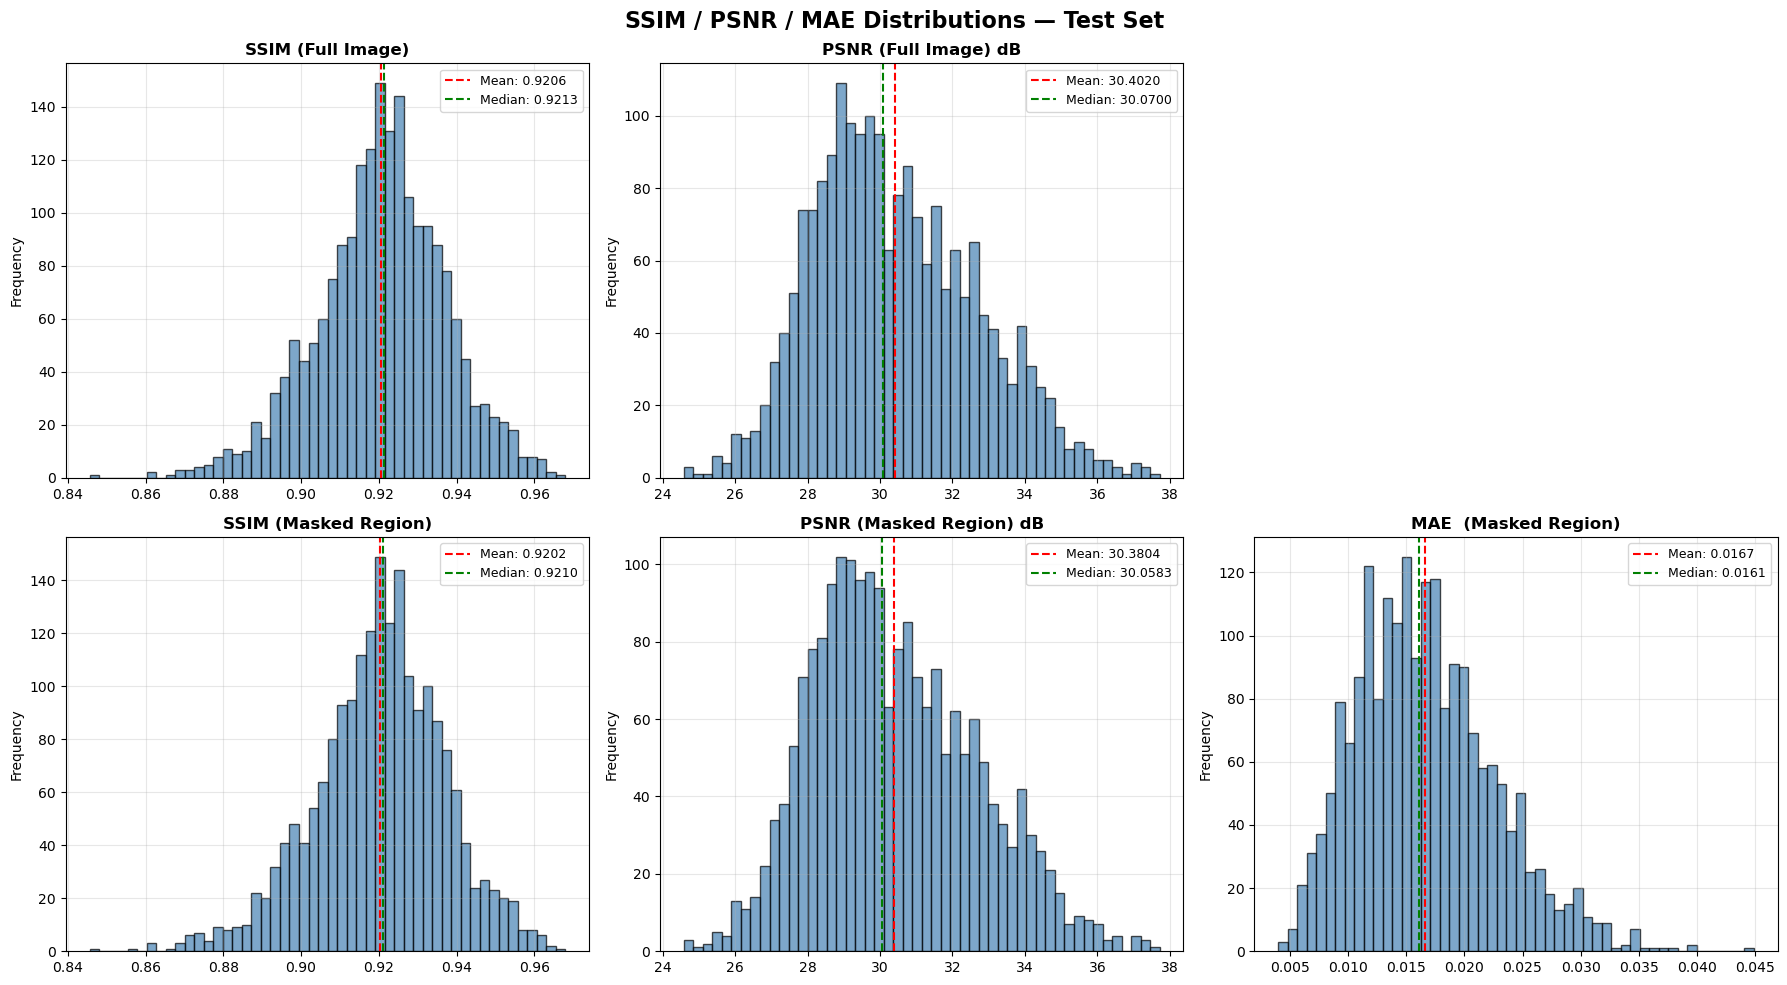


Plot saved to test_results/ssim_psnr_distributions.png
Scores saved to test_results/ssim_psnr_scores.txt


In [5]:
# ============================================================================
# SSIM AND PSNR EVALUATION — Test Set
# ============================================================================

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib.pyplot as plt
import os
CHECKPOINT_PATH = "checkpoints/best_model.pth"   # <-- path to your best .pth
TEST_DIR        = "Project/MRI_DATA/BraTS2021_Training_Data_2D/test"
TARGET_SLICES   = ["slice_77", "slice_75"]
MASK_RATIO      = 0.25
PATCH_SIZE      = 16
BATCH_SIZE      = 16
IMG_SIZE        = 224
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}\n")

# ------------------------------------------------------------------
# 1. Load dataset + model (reuse same setup as FID cell)
# ------------------------------------------------------------------
print("Loading test dataset...")
test_dataset = ImageDataset(
    data_dir=TEST_DIR,
    target_slices=TARGET_SLICES,
    mask_ratio=MASK_RATIO,
    patch_size=PATCH_SIZE,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)
print(f"  Test samples: {len(test_dataset)}")

print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
model = SwinMAE(img_size=IMG_SIZE, patch_size=4, in_chans=1, pretrained=False)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
state_dict = (checkpoint.get("model_state_dict") or
              checkpoint.get("state_dict") or
              checkpoint)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()
print("  Checkpoint loaded.\n")

# ------------------------------------------------------------------
# 2. Run inference and compute metrics per sample
# ------------------------------------------------------------------
all_ssim_full    = []   # SSIM on full image
all_psnr_full    = []   # PSNR on full image
all_ssim_masked  = []   # SSIM on masked regions only
all_psnr_masked  = []   # PSNR on masked regions only
all_mae_masked   = []   # MAE on masked regions only

print("Computing SSIM / PSNR...")

with torch.no_grad():
    for masked_imgs, original_imgs, masks in tqdm(test_loader, desc="  Evaluating"):
        masked_imgs   = masked_imgs.to(DEVICE)
        original_imgs = original_imgs.to(DEVICE)
        masks         = masks.to(DEVICE)

        reconstructed = model(masked_imgs)

        if reconstructed.shape != original_imgs.shape:
            reconstructed = F.interpolate(
                reconstructed,
                size=original_imgs.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        # Denormalize [-1, 1] → [0, 1] for metric computation
        orig_np  = ((original_imgs.cpu().numpy() + 1) / 2).clip(0, 1)  # (B, 1, H, W)
        recon_np = ((reconstructed.cpu().numpy() + 1) / 2).clip(0, 1)
        mask_np  = masks.cpu().numpy()                                   # 1=visible, 0=masked

        batch_size = orig_np.shape[0]
        for i in range(batch_size):
            orig_2d  = orig_np[i, 0]    # (H, W)
            recon_2d = recon_np[i, 0]
            mask_2d  = mask_np[i, 0]
            inv_mask = 1 - mask_2d      # 1 where masked

            # ---- Full image metrics ----
            ssim_full = ssim(orig_2d, recon_2d, data_range=1.0)
            psnr_full = psnr(orig_2d, recon_2d, data_range=1.0)
            all_ssim_full.append(ssim_full)
            all_psnr_full.append(psnr_full)

            # ---- Masked region metrics ----
            masked_pixels = inv_mask > 0.5
            if masked_pixels.sum() > 0:
                mae  = np.abs(orig_2d[masked_pixels] - recon_2d[masked_pixels]).mean()
                
                # Crop bounding box around masked region for SSIM (needs spatial context)
                rows = np.any(inv_mask > 0.5, axis=1)
                cols = np.any(inv_mask > 0.5, axis=0)
                r0, r1 = np.where(rows)[0][[0, -1]]
                c0, c1 = np.where(cols)[0][[0, -1]]
                orig_crop  = orig_2d[r0:r1+1, c0:c1+1]
                recon_crop = recon_2d[r0:r1+1, c0:c1+1]

                # Only compute if crop is large enough for SSIM window
                if orig_crop.shape[0] >= 7 and orig_crop.shape[1] >= 7:
                    ssim_masked = ssim(orig_crop, recon_crop, data_range=1.0)
                    psnr_masked = psnr(orig_crop, recon_crop, data_range=1.0)
                    all_ssim_masked.append(ssim_masked)
                    all_psnr_masked.append(psnr_masked)

                all_mae_masked.append(mae)

# ------------------------------------------------------------------
# 3. Print results
# ------------------------------------------------------------------
def print_stats(name, values):
    arr = np.array(values)
    print(f"  {name}:")
    print(f"    Mean   : {arr.mean():.4f}")
    print(f"    Std    : {arr.std():.4f}")
    print(f"    Median : {np.median(arr):.4f}")
    print(f"    Min    : {arr.min():.4f}")
    print(f"    Max    : {arr.max():.4f}")

print("\n" + "="*50)
print("FULL IMAGE METRICS")
print("="*50)
print_stats("SSIM", all_ssim_full)
print_stats("PSNR (dB)", all_psnr_full)

print("\n" + "="*50)
print("MASKED REGION METRICS")
print("="*50)
print_stats("SSIM", all_ssim_masked)
print_stats("PSNR (dB)", all_psnr_masked)
print_stats("MAE",  all_mae_masked)

# ------------------------------------------------------------------
# 4. Plot distributions
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("SSIM / PSNR / MAE Distributions — Test Set", fontsize=16, fontweight='bold')

metrics = [
    (all_ssim_full,   "SSIM (Full Image)",    axes[0, 0]),
    (all_psnr_full,   "PSNR (Full Image) dB", axes[0, 1]),
    (all_ssim_masked, "SSIM (Masked Region)", axes[1, 0]),
    (all_psnr_masked, "PSNR (Masked Region) dB", axes[1, 1]),
    (all_mae_masked,  "MAE  (Masked Region)", axes[1, 2]),
]

for values, title, ax in metrics:
    arr = np.array(values)
    ax.hist(arr, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(arr.mean(),   color='red',   linestyle='--', label=f'Mean: {arr.mean():.4f}')
    ax.axvline(np.median(arr), color='green', linestyle='--', label=f'Median: {np.median(arr):.4f}')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot (top right)
axes[0, 2].axis('off')

plt.tight_layout()
os.makedirs("test_results", exist_ok=True)
plt.savefig("test_results/ssim_psnr_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to test_results/ssim_psnr_distributions.png")

# ------------------------------------------------------------------
# 5. Save to text file
# ------------------------------------------------------------------
with open("test_results/ssim_psnr_scores.txt", "w") as f:
    f.write("="*50 + "\n")
    f.write("FULL IMAGE METRICS\n")
    f.write("="*50 + "\n")
    for name, values in [("SSIM", all_ssim_full), ("PSNR (dB)", all_psnr_full)]:
        arr = np.array(values)
        f.write(f"{name}: mean={arr.mean():.4f}, std={arr.std():.4f}, median={np.median(arr):.4f}\n")

    f.write("\n" + "="*50 + "\n")
    f.write("MASKED REGION METRICS\n")
    f.write("="*50 + "\n")
    for name, values in [("SSIM", all_ssim_masked), ("PSNR (dB)", all_psnr_masked), ("MAE", all_mae_masked)]:
        arr = np.array(values)
        f.write(f"{name}: mean={arr.mean():.4f}, std={arr.std():.4f}, median={np.median(arr):.4f}\n")

print("Scores saved to test_results/ssim_psnr_scores.txt")